In [202]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

In [203]:
df = pd.read_csv('Big_data_train.csv')

In [204]:
df.head(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [205]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [206]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [208]:
#check unique
df.apply(lambda x: len(x.unique()))

Item_Identifier              1559
Item_Weight                   416
Item_Fat_Content                5
Item_Visibility              7880
Item_Type                      16
Item_MRP                     5938
Outlet_Identifier              10
Outlet_Establishment_Year       9
Outlet_Size                     4
Outlet_Location_Type            3
Outlet_Type                     4
Item_Outlet_Sales            3493
dtype: int64

In [209]:
#check for null values
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [210]:
#check for categorical values
cat_col = []

for x in df.dtypes.index:  
    if df.dtypes[x]=='object':
        cat_col.append(x)

In [211]:
cat_col

['Item_Identifier',
 'Item_Fat_Content',
 'Item_Type',
 'Outlet_Identifier',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type']

In [212]:
cat_col.remove('Item_Identifier')

In [213]:
cat_col.remove('Outlet_Identifier')

In [214]:
cat_col

['Item_Fat_Content',
 'Item_Type',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type']

In [215]:
for col in cat_col:
    print(col)
    print(df[col].value_counts())
    print()

Item_Fat_Content
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

Item_Type
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

Outlet_Size
Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64

Outlet_Location_Type
Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64

Outlet_Type
Outlet_Type
Supermarket Type1    5577
Grocery Store        1083
Supermarket Type3     935
Supermarket Type2   

In [216]:
#filling the null values
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [244]:
table1 = df.pivot_table(values = 'Item_Weight' , index = 'Item_Identifier')
table1


,Item_Weight
Item_Identifier,
DRA12,11.600000
DRA24,17.495041
DRA59,9.416911
DRB01,9.212548
DRB13,6.115000
...,...
NCZ30,7.485378
NCZ41,19.850000
NCZ42,10.500000


In [218]:
miss_bol = df['Item_Weight'].isnull()
miss_bol

0       False
1       False
2       False
3       False
4       False
        ...  
8518    False
8519    False
8520    False
8521    False
8522    False
Name: Item_Weight, Length: 8523, dtype: bool

In [219]:
for i, item in enumerate(df['Item_Identifier']):
    if miss_bol[i]:
        if item in table1:
          df['Item_Weight'][i] = table1.loc[item]['Item_Weight']
        else:
            df['Item_Weight'][i] = np.mean(df['Item_Weight'])

In [220]:
df['Item_Weight'].isnull().sum()

np.int64(0)

In [221]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [222]:
# replace outlet size
df['Outlet_Size'].value_counts()
#df['Outlet_Type'].value_counts()

Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64

In [223]:
# fill it , by grouping in respect of outlet type
table2 = df.pivot_table(values = 'Outlet_Size' , index = 'Outlet_Type',aggfunc = (lambda x:x.mode()[0]))
table2

,Outlet_Size
Outlet_Type,
Grocery Store,Small
Supermarket Type1,Small
Supermarket Type2,Medium
Supermarket Type3,Medium


In [224]:
miss_bool1 = df['Outlet_Size'].isnull()


df.loc[miss_bool1 ,'Outlet_Size'] = df.loc[miss_bool1 ,'Outlet_Type'].apply(lambda x:table2.loc[x,'Outlet_Size'])




In [225]:
df['Outlet_Size'].isnull().sum()

np.int64(0)

In [226]:
sum(df['Item_Visibility']==0)

526

In [227]:
#replace zeros with mean
df.iloc[:,df['Item_Visibility']].replace([0],[df['Item_Visibility'].mean()],inplace = True )

In [228]:
sum(df['Item_Visibility']==0)

526

In [229]:
# combine them into one
df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [230]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({'LF':'Low Fat', 'low fat':'Low Fat','reg':'Regular'})
df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

In [231]:
#create attribute
df['Item_Identifier'].value_counts()

Item_Identifier
FDW13    10
FDG33    10
NCY18     9
FDD38     9
DRE49     9
         ..
FDY43     1
FDQ60     1
FDO33     1
DRF48     1
FDC23     1
Name: count, Length: 1559, dtype: int64

In [ ]:
df['new_item'] = df['Item_Identifier'].apply(lambda x: x[:2])
df['new_item']

In [233]:
df['new_item']= df['new_item'].map({'FD':'FOOD','DR':'DRINK','NC':'NON_CONSUMABLE'})

In [240]:
df['new_item'].value_counts()

new_item
FOOD              6125
NON_CONSUMABLE    1599
DRINK              799
Name: count, dtype: int64

In [238]:
df.loc[df['new_item']=='NON_CONSUMABLE','Item_Fat_Content'] = 'Non-Edible'
df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat       3918
Regular       3006
Non-Edible    1599
Name: count, dtype: int64

In [247]:
# we will create a new attribute for the year established  as the numbers are too big

df['Outlet_Year'] = 2013 - df['Outlet_Establishment_Year']
df['Outlet_Year']

0       14
1        4
2       14
3       15
4       26
        ..
8518    26
8519    11
8520     9
8521     4
8522    16
Name: Outlet_Year, Length: 8523, dtype: int64

In [248]:
df.head(10)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,new_item,Outlet_Year
0,FDA15,9.300000,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,FOOD,14
1,DRC01,5.920000,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,DRINK,4
2,FDN15,17.500000,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,FOOD,14
3,FDX07,19.200000,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800,FOOD,15
4,NCD19,8.930000,Non-Edible,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,NON_CONSUMABLE,26
5,FDP36,10.395000,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088,FOOD,4
6,FDO10,13.650000,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528,FOOD,26
7,FDP10,12.857645,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636,FOOD,28
8,FDH17,16.200000,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,Small,Tier 2,Supermarket Type1,1076.5986,FOOD,11
9,FDU28,19.200000,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,Small,Tier 2,Supermarket Type1,4710.5350,FOOD,6


<h2>EDA</h2>

<Axes: xlabel='Item_Weight', ylabel='Density'>

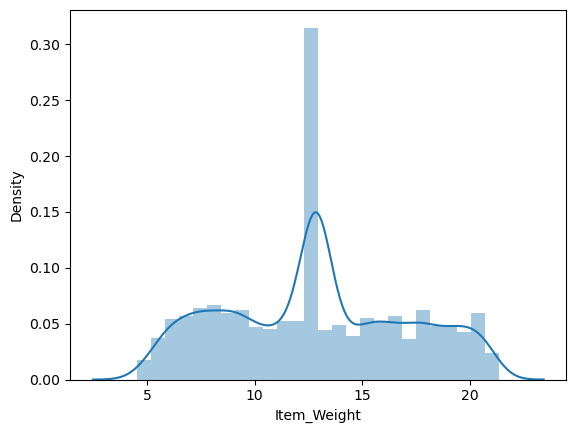

In [249]:
sns.distplot(df['Item_Weight'])

<Axes: xlabel='Item_Visibility', ylabel='Density'>

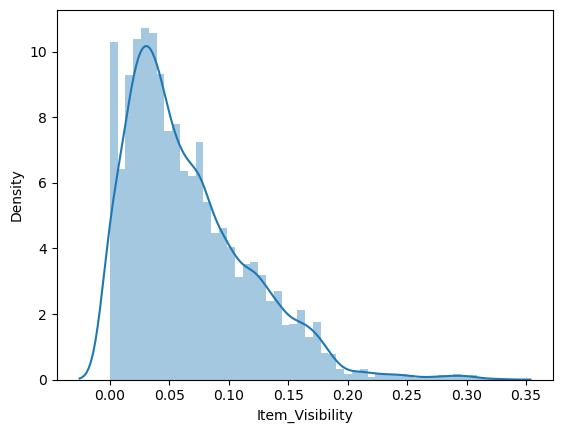

In [252]:
sns.distplot(df['Item_Visibility'])


<Axes: xlabel='Item_MRP', ylabel='Density'>

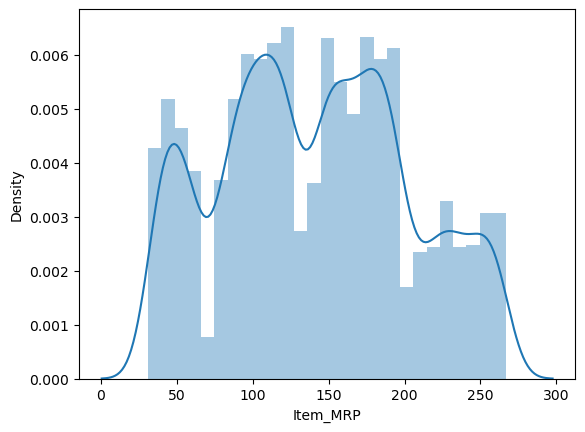

In [253]:
sns.distplot(df['Item_MRP'])

<Axes: xlabel='Item_Outlet_Sales', ylabel='Density'>

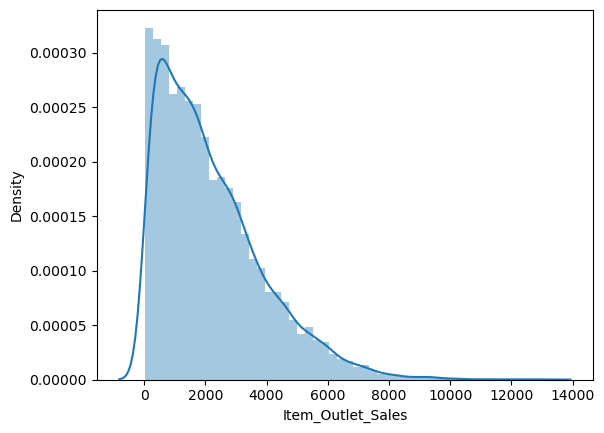

In [254]:
sns.distplot(df['Item_Outlet_Sales'])

In [255]:
# to normalize the above feature
df['Item_Outlet_Sales'] = np.log(1+df['Item_Outlet_Sales'])

<Axes: xlabel='Item_Outlet_Sales', ylabel='Density'>

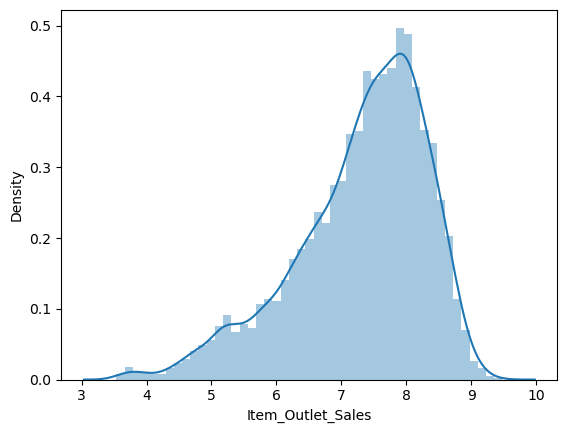

In [256]:
sns.distplot(df['Item_Outlet_Sales'])

<Axes: ylabel='count'>

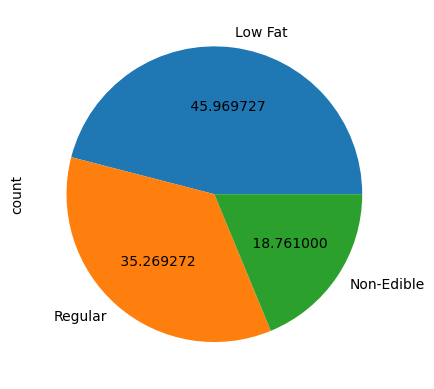

In [264]:
df['Item_Fat_Content'].value_counts().plot(kind = 'pie',autopct =' %2f')

<Axes: ylabel='count'>

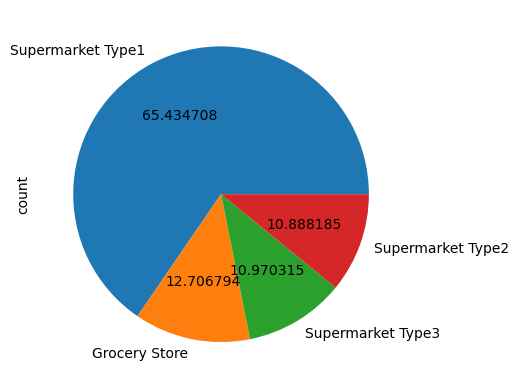

In [265]:
df['Outlet_Type'].value_counts().plot(kind = 'pie', autopct = '%2f')

<Axes: xlabel='count', ylabel='Item_Type'>

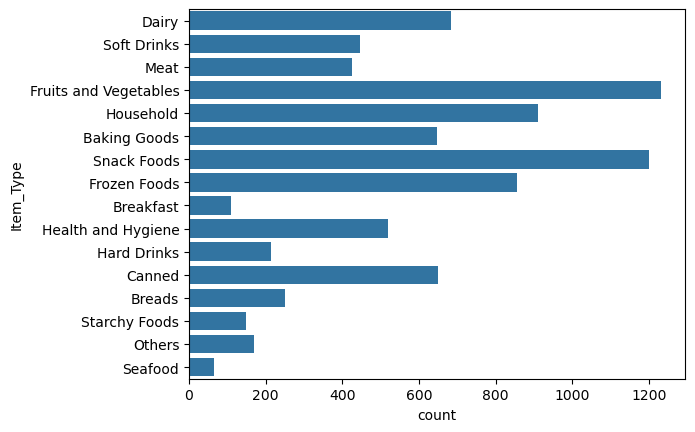

In [272]:
sns.countplot(df['Item_Type'])

<Axes: xlabel='count', ylabel='Outlet_Location_Type'>

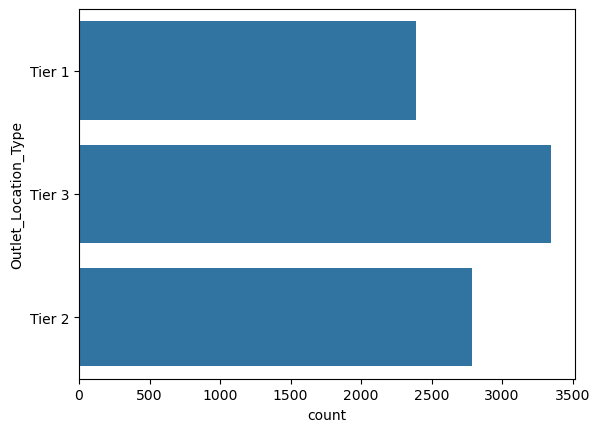

In [271]:
sns.countplot(df['Outlet_Location_Type'])

<Axes: xlabel='count', ylabel='Outlet_Type'>

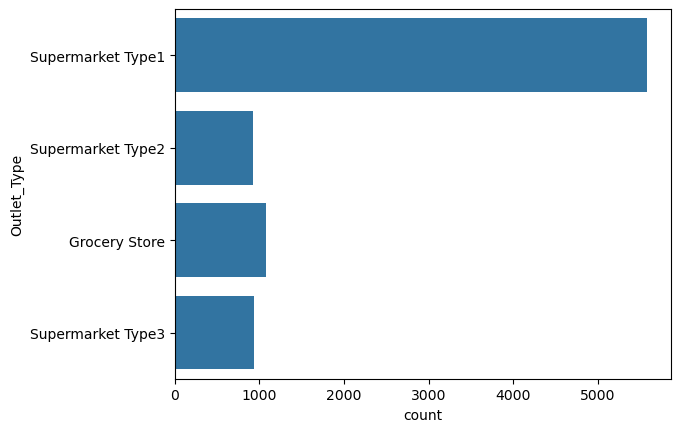

In [273]:
sns.countplot(df['Outlet_Type'])

<h1>LABEL ENCODING</h1>

In [275]:
from sklearn.preprocessing import LabelEncoder

In [276]:
le = LabelEncoder()

In [278]:
df.head(2)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,new_item,Outlet_Year
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,8.225808,FOOD,14
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,6.096776,DRINK,4


In [279]:
cols = ['Item_Fat_Content','Item_Type','Outlet_Size','Outlet_Location_Type','Outlet_Type','new_item']

In [280]:
for x in cols:
    df[x] = le.fit_transform(df[x])

In [281]:
df.head(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,new_item,Outlet_Year
0,FDA15,9.30,0,0.016047,4,249.8092,OUT049,1999,1,0,1,8.225808,1,14
1,DRC01,5.92,2,0.019278,14,48.2692,OUT018,2009,1,2,2,6.096776,0,4
2,FDN15,17.50,0,0.016760,10,141.6180,OUT049,1999,1,0,1,7.648868,1,14
3,FDX07,19.20,2,0.000000,6,182.0950,OUT010,1998,2,2,0,6.597664,1,15
4,NCD19,8.93,1,0.000000,9,53.8614,OUT013,1987,0,2,1,6.903451,2,26


<h1>TRAIN TEST SPLIT</h1>

In [283]:
X = df.drop(columns = ['Outlet_Establishment_Year' ,'Item_Identifier','Outlet_Identifier' ,'Item_Outlet_Sales'])
Y = df['Item_Outlet_Sales']

## Model Training

In [285]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

In [314]:
def training(model , X,Y):
    #training 
    model.fit(X,Y)

    #prediciting the dataset
    predict = model.predict(X)

    #perform cross-validation
    cross =  cross_val_score(model,X,Y,scoring = 'neg_mean_squared_error')

    print('Model Report')
    print('Cross Validation: ',cross)
    print('Mean Square Error: ', mean_squared_error(Y,predict))  
    

In [315]:
from sklearn.linear_model import LinearRegression

In [316]:
model =  LinearRegression()

In [317]:
training(model,X,Y)

Model Report
Cross Validation:  [-0.44424671 -0.42686587 -0.43891231 -0.44724199 -0.45089183]
Mean Square Error:  0.4404405244311415
